In [21]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

In [22]:
# Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize and reshape data
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

Noise Factor: 0.8. I think is the limit but it depends what your goal is.

In [23]:
noise_factor = 0.8 

# Add noise to the images
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

In [24]:
# Define the autoencoder model architecture
input_img = Input(shape=(28, 28, 1))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


In [25]:
# Fit the model without callbacks or validation
history = autoencoder.fit(x_train_noisy, x_train,
                epochs=100,
                batch_size=128,
                shuffle=True)

Epoch 1/100
469/469 [==============================] - 50s 105ms/step - loss: 0.2016
Epoch 2/100
469/469 [==============================] - 49s 105ms/step - loss: 0.1579
Epoch 3/100
469/469 [==============================] - 49s 105ms/step - loss: 0.1508
Epoch 4/100
469/469 [==============================] - 49s 104ms/step - loss: 0.1461
Epoch 5/100
469/469 [==============================] - 49s 104ms/step - loss: 0.1434
Epoch 6/100
469/469 [==============================] - 48s 102ms/step - loss: 0.1418
Epoch 7/100
469/469 [==============================] - 48s 102ms/step - loss: 0.1405
Epoch 8/100
469/469 [==============================] - 50s 107ms/step - loss: 0.1393
Epoch 9/100
469/469 [==============================] - 48s 103ms/step - loss: 0.1384
Epoch 10/100
469/469 [==============================] - 48s 103ms/step - loss: 0.1377
Epoch 11/100
469/469 [==============================] - 48s 102ms/step - loss: 0.1370
Epoch 12/100
469/469 [==============================] - 48s 102

313/313 [==============================] - 2s 6ms/step


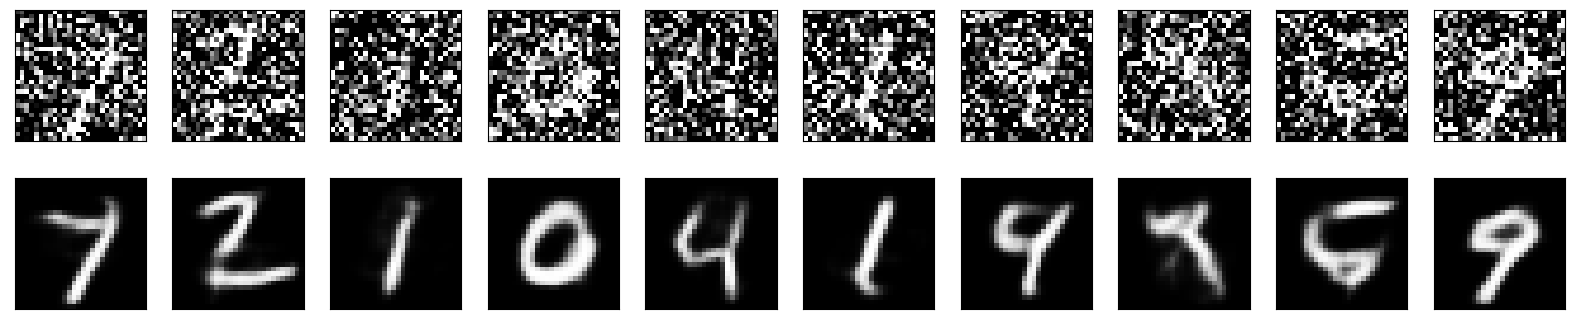

In [26]:
# Display noisy images and their corresponding denoised images
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


Code to see what Noise Level is Best Is below As it takes forever to run 100 epochs


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

In [28]:
# Load MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Normalize and reshape data
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

In [29]:
# Define the autoencoder model architecture
input_img = Input(shape=(28, 28, 1))
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')


Epoch 1/100
469/469 [==============================] - 45s 94ms/step - loss: 0.2100
Epoch 2/100
469/469 [==============================] - 44s 94ms/step - loss: 0.1582
Epoch 3/100
469/469 [==============================] - 44s 94ms/step - loss: 0.1516
Epoch 4/100
469/469 [==============================] - 45s 95ms/step - loss: 0.1477
Epoch 5/100
469/469 [==============================] - 44s 95ms/step - loss: 0.1451
Epoch 6/100
469/469 [==============================] - 45s 97ms/step - loss: 0.1435
Epoch 7/100
469/469 [==============================] - 45s 96ms/step - loss: 0.1422
Epoch 8/100
469/469 [==============================] - 45s 95ms/step - loss: 0.1411
Epoch 9/100
469/469 [==============================] - 45s 96ms/step - loss: 0.1401
Epoch 10/100
469/469 [==============================] - 45s 96ms/step - loss: 0.1392
Epoch 11/100
469/469 [==============================] - 45s 95ms/step - loss: 0.1386
Epoch 12/100
469/469 [==============================] - 45s 96ms/step - lo

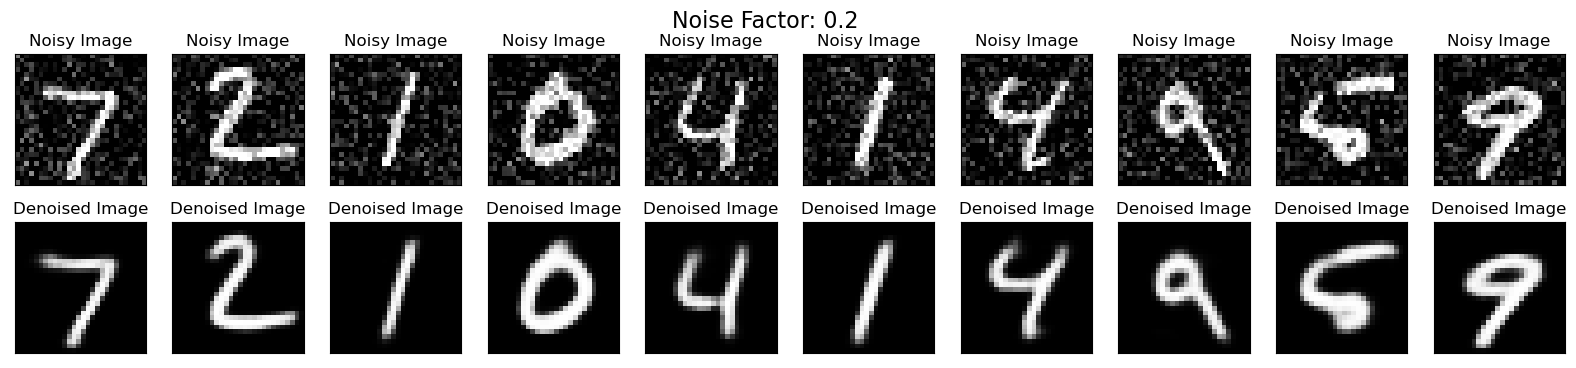

Noise Factor: 0.2, MSE: 0.008870875462889671
313/313 [==============================] - 2s 6ms/step


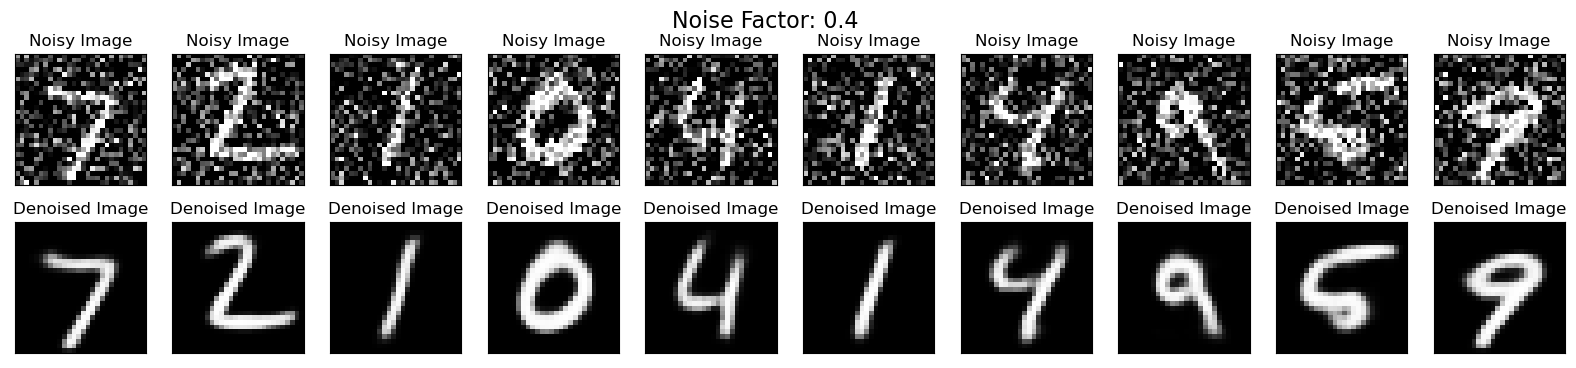

Noise Factor: 0.4, MSE: 0.010628346353769302
313/313 [==============================] - 2s 6ms/step


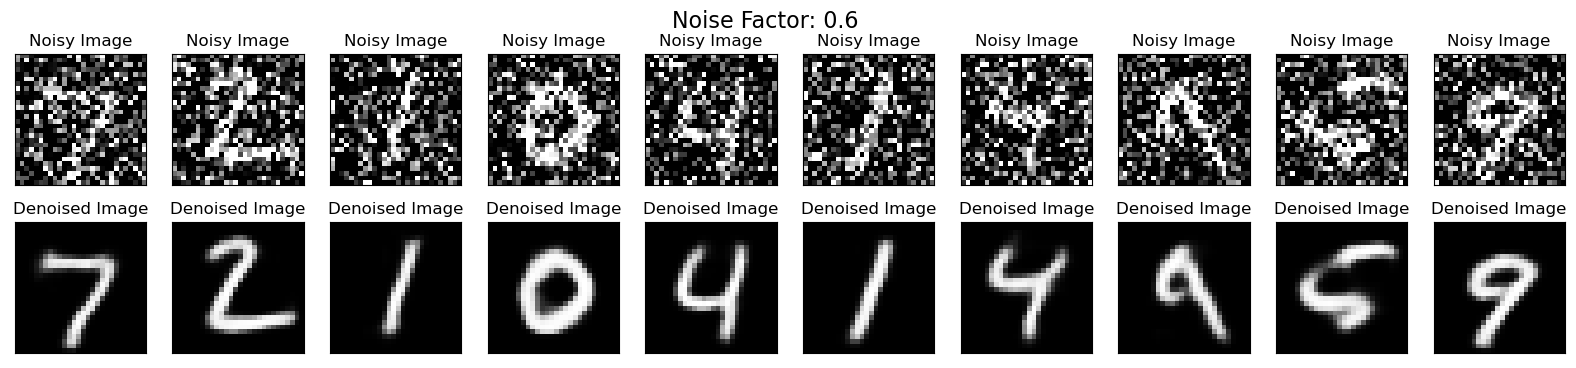

Noise Factor: 0.6, MSE: 0.014748791232705116
313/313 [==============================] - 2s 7ms/step


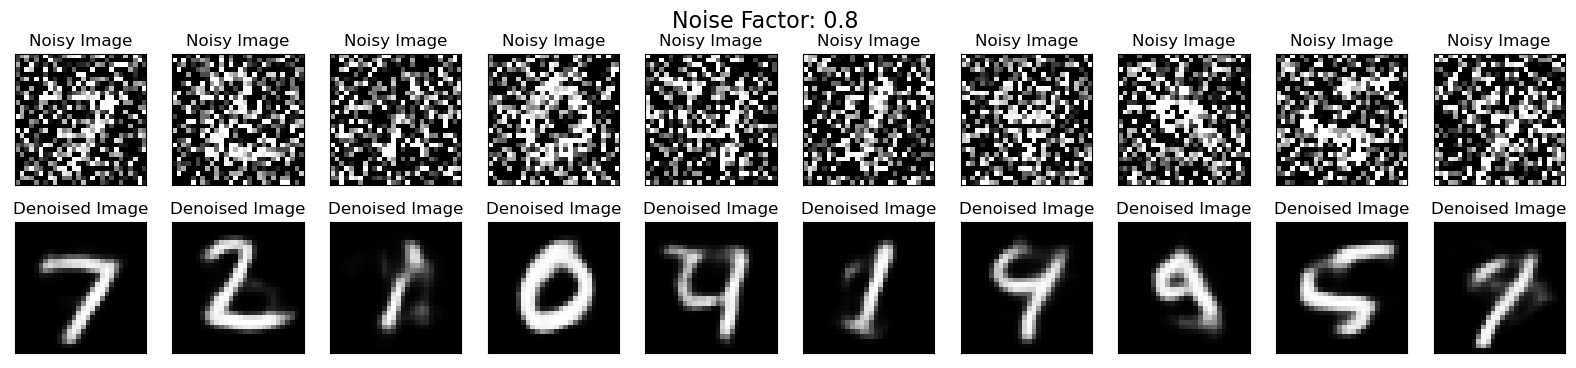

Noise Factor: 0.8, MSE: 0.021863145753741264
313/313 [==============================] - 2s 6ms/step


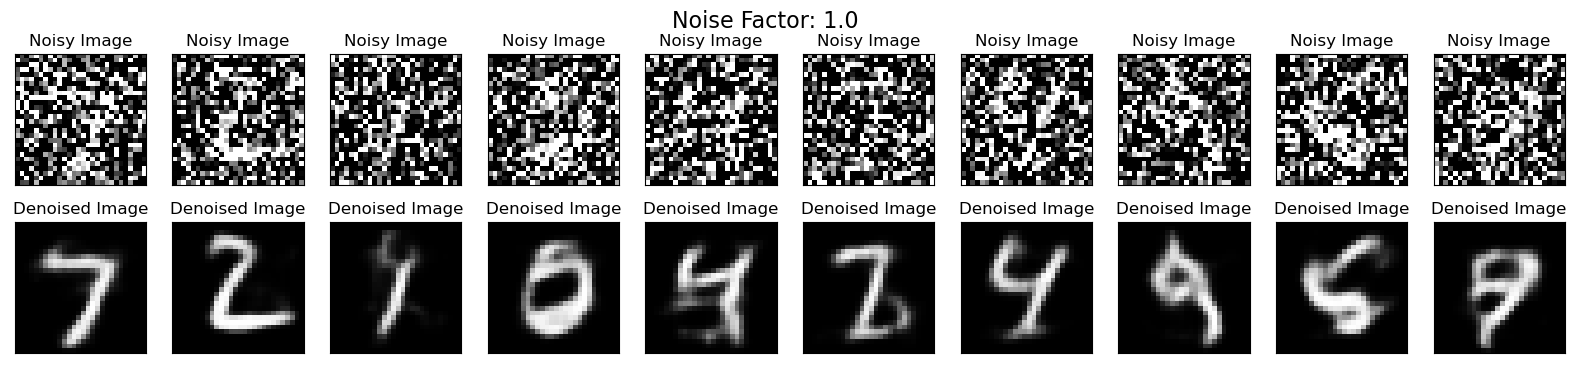

Noise Factor: 1.0, MSE: 0.03141273930668831


In [30]:
def calculate_mse(original_images, denoised_images):
    squared_diff = np.square(original_images - denoised_images)
    mse = np.mean(squared_diff)
    return mse

# Fit the model without callbacks or validation
history = autoencoder.fit(x_train_noisy, x_train,
                epochs=100,
                batch_size=128,
                shuffle=True)

# Define a range of noise factors to test
noise_factors = [0.2, 0.4, 0.6, 0.8, 1.0]

# Iterate over noise factors
for noise_factor in noise_factors:
    # Add noise to test images
    x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
    x_test_noisy = np.clip(x_test_noisy, 0., 1.)
    
    # Denoise the images using the trained autoencoder model
    decoded_imgs = autoencoder.predict(x_test_noisy)
    
    # Visualize the denoising results
    n = 10
    plt.figure(figsize=(20, 4))
    for i in range(n):
        # display original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test_noisy[i].reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        ax.set_title('Noisy Image')
        
        # display reconstruction
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(28, 28))
        plt.gray()
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        ax.set_title('Denoised Image')
    
    plt.suptitle(f"Noise Factor: {noise_factor}", fontsize=16)
    plt.show()
    
    # Evaluate the denoising performance (MSE)
    mse = calculate_mse(x_test, decoded_imgs)
    print(f"Noise Factor: {noise_factor}, MSE: {mse}")